# Perceptron Classification on Breast Cancer Dataset

In this notebook, we demonstrate the performance of a Perceptron classifier on a real-world dataset.

The Perceptron is a linear classification algorithm that attempts to find a hyperplane that separates two classes. It is guaranteed to converge only when the data is linearly separable.

We use the Breast Cancer Wisconsin Dataset, which contains features computed from digitized images of breast mass samples.

## Objectives
- Load and preprocess real-world data
- Train a Perceptron model from scratch
- Evaluate model performance
- Visualize decision boundaries
- Analyze convergence behavior

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rice_ml import StandardScaler, train_test_split
from rice_ml import accuracy_score, confusion_matrix

from mlxtend.plotting import plot_decision_regions

sns.set_theme()

## Loading the Dataset

We load the dataset directly from the UCI repository. The dataset includes:
- 30 numerical features
- A diagnosis label:
    - M = Malignant
    - B = Benign

We convert labels to:
- -1 = Malignant
- 1 = Benign

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

columns = ["id", "diagnosis"] + [f"feature_{i}" for i in range(30)]

df = pd.read_csv(url, header=None, names=columns)

# Drop ID column
df = df.drop("id", axis=1)

# Convert labels
df["diagnosis"] = df["diagnosis"].map({"M": -1, "B": 1})

df.head()

,diagnosis,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29
0,-1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,-1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,-1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,-1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,-1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Exploratory Data Analysis

We examine:
- Class distribution
- Feature relationships
- Correlations

Understanding the data helps us anticipate whether the Perceptron will perform well.

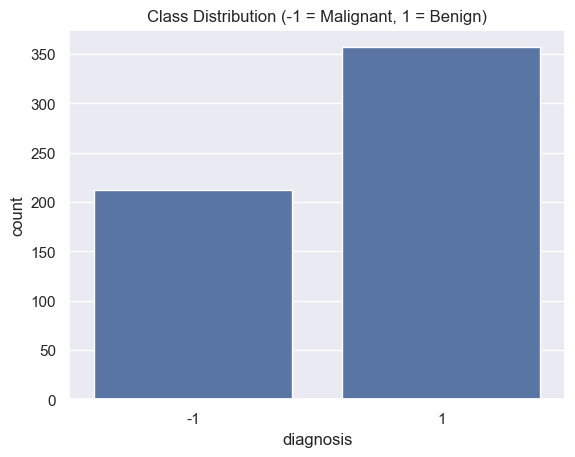

In [3]:
# Class distribution
sns.countplot(x=df["diagnosis"])
plt.title("Class Distribution (-1 = Malignant, 1 = Benign)")
plt.show()

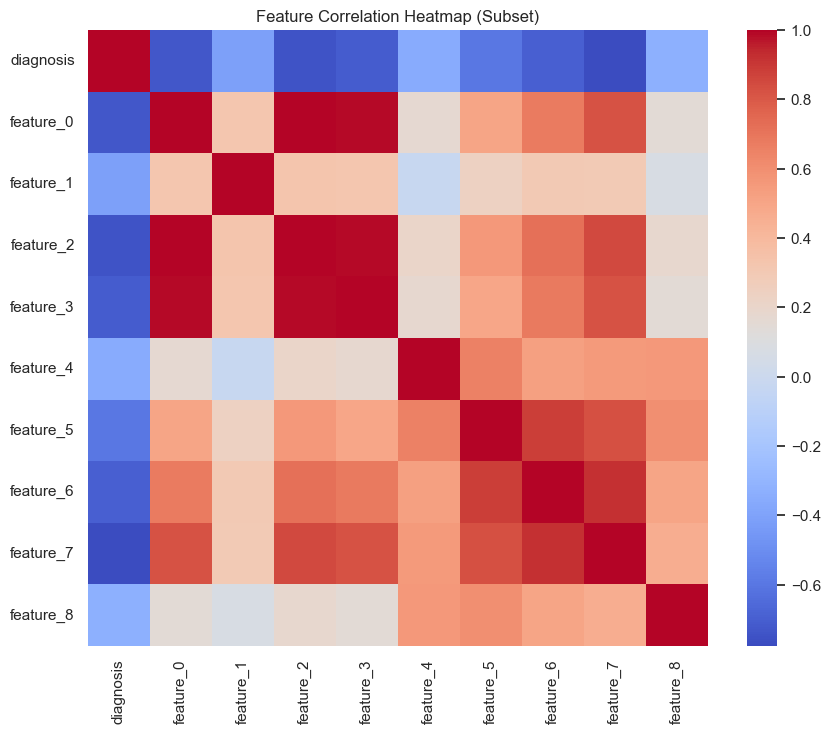

In [4]:
# Correlation heatmap (subset for readability)
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :10].corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap (Subset)")
plt.show()

## Data Preprocessing

We:
- Separate features and labels
- Standardize features (important for Perceptron)
- Split into training and testing sets

In [5]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

## Training the Perceptron

We train our Perceptron model and observe whether it converges.

If the dataset is close to linearly separable, we expect:
- Fast convergence
- Low classification error

In [6]:
from rice_ml import Perceptron

model = Perceptron(learning_rate=0.01, epochs=100)
model.train(X_train, y_train)

## Model Evaluation

We evaluate the model using:
- Accuracy
- Confusion matrix

These metrics help us understand how well the model distinguishes between malignant and benign cases.

In [7]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")

cm = confusion_matrix(y_test, y_pred, labels=[1, -1])
print("Confusion Matrix:\n", cm)

Test Accuracy: 97.39%
Confusion Matrix:
 [[71  1]
 [ 2 41]]


## Training Convergence

We plot the number of misclassifications per epoch.

If the Perceptron converges, the error should approach zero.

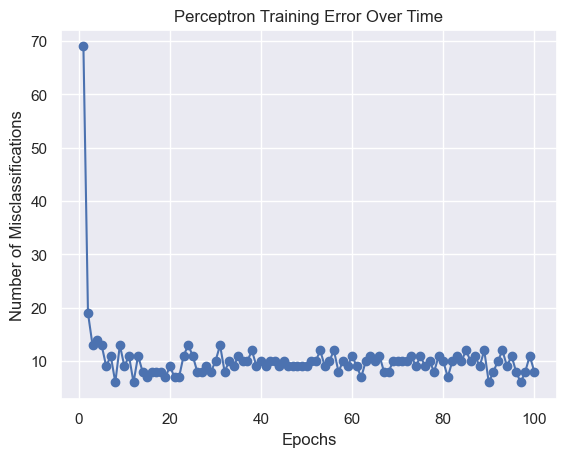

In [8]:
plt.plot(range(1, len(model.errors_) + 1), model.errors_, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Number of Misclassifications")
plt.title("Perceptron Training Error Over Time")
plt.show()

## Decision Boundary Visualization

Since we cannot visualize 30 dimensions, we select two features and plot the decision boundary.

This helps us understand whether the classes are linearly separable in lower dimensions.

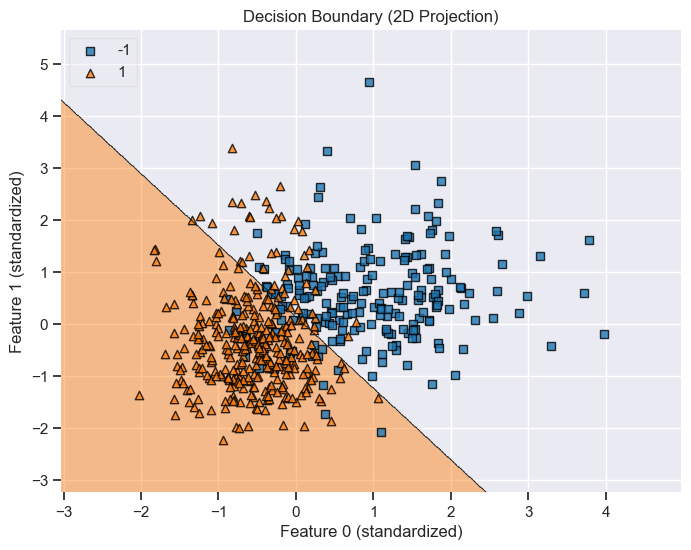

In [9]:
# Select two features
X_pair = X_scaled[:, [0, 1]]

model_2d = Perceptron(learning_rate=0.01, epochs=100)
model_2d.train(X_pair, y)

plt.figure(figsize=(8, 6))
plot_decision_regions(X=X_pair, y=y.to_numpy(), clf=model_2d, legend=2)

plt.xlabel("Feature 0 (standardized)")
plt.ylabel("Feature 1 (standardized)")
plt.title("Decision Boundary (2D Projection)")
plt.show()

## Final Analysis

### Key Observations:
- The Perceptron achieves high accuracy, suggesting the dataset is close to linearly separable.
- The training error decreases rapidly, indicating fast convergence.
- Feature scaling significantly improves performance.

### Limitations:
- The Perceptron struggles with non-linearly separable data.
- It cannot model complex decision boundaries.

### Conclusion:
The Perceptron is effective for simple, linearly separable datasets, but more advanced models are needed for complex data distributions.